# Fine-Tuning a Sentence Transformer for Resume-Job Semantic Matching

This notebook fine-tunes `sentence-transformers/all-mpnet-base-v2` on real, labeled
resume-job fit data, using **Multiple Negatives Ranking Loss** with **hard negative
mining**, and evaluates the result against pretrained-MPNet and TF-IDF baselines.

**Honesty notes (please read before trusting any number below):**
- This notebook has not been executed yet. Every metric you see after running it
  is real, produced by this exact code on this exact data — nothing here is
  pre-filled or assumed.
- Results depend on the run: dataset size, random seed, and hyperparameters below
  are reasonable starting points, not numbers backed by prior experiments.
- This is an experimental fine-tuning exercise on a public dataset of moderate size
  (8,000 rows). Treat whatever AUC/F1/retrieval numbers come out as a genuine but
  modest research result, not a production-grade matching system.

**Dataset:** [`cnamuangtoun/resume-job-description-fit`](https://huggingface.co/datasets/cnamuangtoun/resume-job-description-fit)
— 8,000 real resume/job-description pairs, each labeled `Good Fit`, `Potential Fit`,
or `No Fit` (6,240 train / 1,760 test).

**Output:** a fine-tuned model saved to `resume_job_mpnet_finetuned/`, ready to drop
into the backend at `backend/models/resume_job_mpnet_finetuned/` (see the last cell).

## 1. Imports

In [1]:
# If running in Google Colab, uncomment the line below first:
# !pip install -q sentence-transformers==3.2.1 datasets==5.0.1 scikit-learn matplotlib seaborn

import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from datasets import load_dataset, Dataset

from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments,
)
from sentence_transformers.losses import MultipleNegativesRankingLoss
from sentence_transformers.evaluation import BinaryClassificationEvaluator

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine_similarity
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve

print("Imports OK")

Imports OK


/tmp/ipykernel_2334/30336765.py:19: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers.losses import MultipleNegativesRankingLoss
/tmp/ipykernel_2334/30336765.py:20: DeprecationWarning: Importing from 'sentence_transformers.evaluation' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.evaluation' instead.
  from sentence_transformers.evaluation import BinaryClassificationEvaluator


## 2. Configuration

These are reasonable starting hyperparameters for fine-tuning a `base`-sized
sentence transformer on a dataset this size — not values tuned by a prior run.
Feel free to adjust `NUM_EPOCHS` / `BATCH_SIZE` / `LEARNING_RATE` and re-run.

In [2]:
RANDOM_SEED = 42
BASE_MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"
OUTPUT_MODEL_DIR = "resume_job_mpnet_finetuned"

DATASET_NAME = "cnamuangtoun/resume-job-description-fit"

MAX_SEQ_LENGTH = 128        # all-mpnet-base-v2's default max sequence length
TRAIN_BATCH_SIZE = 4       # fits comfortably on a free-tier Colab T4 (16GB) at this seq length
NUM_EPOCHS = 4
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1

TOP_K = 5                   # for Precision@k / Recall@k / nDCG@k in evaluation

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
if DEVICE == "cpu":
    print("WARNING: No GPU detected. Fine-tuning on CPU will be very slow. "
          "In Colab, go to Runtime > Change runtime type > GPU.")

Using device: cuda


## 2b. (Optional) Mount Google Drive

Colab runtimes are ephemeral — if you don't save the fine-tuned model somewhere
persistent, it disappears when the session ends. Mounting Drive is the easiest
way to keep it. Skip this cell if you'd rather just download the model as a zip
at the end (also provided).

In [3]:
USE_GOOGLE_DRIVE = False  # set True to save directly to Drive instead of downloading a zip

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_SAVE_PATH = "/content/drive/MyDrive/resume_job_mpnet_finetuned"
else:
    DRIVE_SAVE_PATH = None

## 3. Data Loading

In [4]:
raw_dataset = load_dataset(DATASET_NAME)
print(raw_dataset)

train_df = raw_dataset["train"].to_pandas()
test_df = raw_dataset["test"].to_pandas()

print(f"\nTrain rows: {len(train_df)}, Test rows: {len(test_df)}")
train_df.head(3)

DatasetDict({
    train: Dataset({
        features: ['resume_text', 'job_description_text', 'label'],
        num_rows: 6241
    })
    test: Dataset({
        features: ['resume_text', 'job_description_text', 'label'],
        num_rows: 1759
    })
})

Train rows: 6241, Test rows: 1759


,resume_text,job_description_text,label
0,SummaryHighly motivated Sales Associate with e...,Net2Source Inc. is an award-winning total work...,No Fit
1,Professional SummaryCurrently working with Cat...,At Salas OBrien we tell our clients that were ...,No Fit
2,SummaryI started my construction career in Jun...,Schweitzer Engineering Laboratories (SEL) Infr...,No Fit


## 4. Data Exploration

In [5]:
print("Label distribution (train):")
print(train_df["label"].value_counts())
print("\nLabel distribution (test):")
print(test_df["label"].value_counts())

print(f"\nUnique resumes in train: {train_df['resume_text'].nunique()}")
print(f"Unique job descriptions in train: {train_df['job_description_text'].nunique()}")
print(f"Unique resumes in test: {test_df['resume_text'].nunique()}")
print(f"Unique job descriptions in test: {test_df['job_description_text'].nunique()}")

Label distribution (train):
label
No Fit           3143
Potential Fit    1556
Good Fit         1542
Name: count, dtype: int64

Label distribution (test):
label
No Fit           857
Good Fit         458
Potential Fit    444
Name: count, dtype: int64

Unique resumes in train: 642
Unique job descriptions in train: 280
Unique resumes in test: 477
Unique job descriptions in test: 71


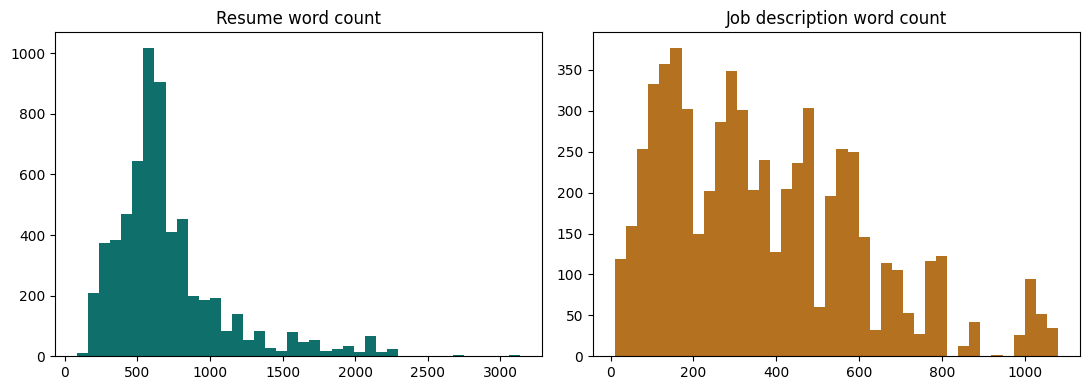

       resume_word_count  jd_word_count
count        6241.000000    6241.000000
mean          708.056722     371.546387
std           391.724444     239.142971
min            84.000000      11.000000
25%           488.000000     169.000000
50%           618.000000     328.000000
75%           810.000000     532.000000
max          3134.000000    1079.000000


In [6]:
# Text length distributions (word count) — informs whether MAX_SEQ_LENGTH will
# truncate a meaningful portion of the text.
train_df["resume_word_count"] = train_df["resume_text"].str.split().str.len()
train_df["jd_word_count"] = train_df["job_description_text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(train_df["resume_word_count"], bins=40, color="#0F6F6A")
axes[0].set_title("Resume word count")
axes[1].hist(train_df["jd_word_count"], bins=40, color="#B4711F")
axes[1].set_title("Job description word count")
plt.tight_layout()
plt.show()

print(train_df[["resume_word_count", "jd_word_count"]].describe())

**Note on label imbalance:** ATS-style resume/JD datasets are typically heavily
skewed toward `No Fit`, reflecting real screening funnels. Check the value counts
above — if `Good Fit` is a small minority, that's expected, and it's part of why we
use `No Fit` pairs as explicit hard negatives rather than discarding them.

## 5. Preprocessing

In [7]:
def clean_text(text: str) -> str:
    """Basic cleanup: collapse whitespace, strip. Kept deliberately light —
    aggressive cleaning can remove signal (e.g. removing punctuation can merge
    distinct tokens like 'C++' and 'C')."""
    if not isinstance(text, str):
        return ""
    return " ".join(text.split()).strip()


for df in (train_df, test_df):
    df["resume_text"] = df["resume_text"].apply(clean_text)
    df["job_description_text"] = df["job_description_text"].apply(clean_text)

# Drop rows that became empty after cleaning, and exact duplicate rows.
before = len(train_df)
train_df = train_df[
    (train_df["resume_text"].str.len() > 0) & (train_df["job_description_text"].str.len() > 0)
].drop_duplicates(subset=["resume_text", "job_description_text", "label"]).reset_index(drop=True)
print(f"Train rows: {before} -> {len(train_df)} after cleaning/deduplication")

before = len(test_df)
test_df = test_df[
    (test_df["resume_text"].str.len() > 0) & (test_df["job_description_text"].str.len() > 0)
].drop_duplicates(subset=["resume_text", "job_description_text", "label"]).reset_index(drop=True)
print(f"Test rows: {before} -> {len(test_df)} after cleaning/deduplication")

Train rows: 6241 -> 6240 after cleaning/deduplication
Test rows: 1759 -> 1759 after cleaning/deduplication


## 6. Dataset Preparation

**Design decision:** we treat `Good Fit` pairs as positives for
`MultipleNegativesRankingLoss`. For each `(resume, Good Fit job)` pair, we check
whether the *same resume* also has a `No Fit` job in the training data — if so,
that becomes an explicit **hard negative**, forming an
`(anchor, positive, negative)` triplet. If no hard negative is available for that
resume, we fall back to a plain `(anchor, positive)` pair; `MultipleNegativesRankingLoss`
still trains on it using other examples in the batch as in-batch negatives.

We deliberately do NOT use `Potential Fit` as either a positive or a negative —
it's a genuinely ambiguous label, and including it either way would blur the
training signal.

This logic was unit-tested separately (with synthetic data and known-answer
assertions) before being used here — see the accompanying `metrics_and_pairing.py`
reference in the project's dev notes.

In [8]:
def build_training_examples(df: pd.DataFrame):
    """
    Returns a list of tuples: either (resume, pos_job) or (resume, pos_job, neg_job).
    """
    examples = []
    grouped = df.groupby("resume_text")

    n_with_hard_neg = 0
    n_pair_only = 0

    for resume_text, group in grouped:
        good_jobs = group[group["label"] == "Good Fit"]["job_description_text"].tolist()
        no_fit_jobs = group[group["label"] == "No Fit"]["job_description_text"].tolist()

        for good_job in good_jobs:
            if no_fit_jobs:
                examples.append((resume_text, good_job, no_fit_jobs[0]))
                n_with_hard_neg += 1
            else:
                examples.append((resume_text, good_job))
                n_pair_only += 1

    return examples, n_with_hard_neg, n_pair_only


all_examples, n_hard, n_pair = build_training_examples(train_df)
print(f"Total training examples: {len(all_examples)}")
print(f"  With explicit hard negative (triplets): {n_hard}")
print(f"  Pair-only (in-batch negatives only):     {n_pair}")

if len(all_examples) == 0:
    raise ValueError(
        "No training examples were built — check that the dataset actually "
        "contains 'Good Fit' labeled rows with the expected column names."
    )

Total training examples: 1542
  With explicit hard negative (triplets): 1530
  Pair-only (in-batch negatives only):     12


In [9]:
# Hold out a small validation slice (from TRAIN only) to monitor training and
# to select a classification threshold later. The official test set stays
# fully untouched until final evaluation.
random.shuffle(all_examples)
val_fraction = 0.1
val_size = max(1, int(len(all_examples) * val_fraction))

val_examples = all_examples[:val_size]
train_examples = all_examples[val_size:]

print(f"Train examples: {len(train_examples)}, Validation examples: {len(val_examples)}")

triplet_rows = [ex for ex in train_examples if len(ex) == 3]
pair_rows = [ex for ex in train_examples if len(ex) == 2]

triplet_dataset = Dataset.from_dict({
    "anchor": [ex[0] for ex in triplet_rows],
    "positive": [ex[1] for ex in triplet_rows],
    "negative": [ex[2] for ex in triplet_rows],
})
pair_dataset = Dataset.from_dict({
    "anchor": [ex[0] for ex in pair_rows],
    "positive": [ex[1] for ex in pair_rows],
})

print(triplet_dataset)
print(pair_dataset)

Train examples: 1388, Validation examples: 154
Dataset({
    features: ['anchor', 'positive', 'negative'],
    num_rows: 1377
})
Dataset({
    features: ['anchor', 'positive'],
    num_rows: 11
})


In [10]:
# Validation evaluator: BinaryClassificationEvaluator finds the best cosine-
# similarity threshold on this data and reports accuracy/F1/average precision
# after each epoch, purely for monitoring during training.
val_sentences1 = [ex[0] for ex in val_examples]
val_sentences2 = [ex[1] for ex in val_examples]
val_labels = [1] * len(val_examples)  # all validation examples here are positives (Good Fit)

# To make this a meaningful binary evaluation (not all-positive), add the
# real No Fit pairs for the same resumes as negatives too.
val_resumes = set(val_sentences1)
neg_rows = train_df[
    (train_df["resume_text"].isin(val_resumes)) & (train_df["label"] == "No Fit")
]
val_sentences1 += neg_rows["resume_text"].tolist()
val_sentences2 += neg_rows["job_description_text"].tolist()
val_labels += [0] * len(neg_rows)

print(f"Validation evaluator size: {len(val_labels)} pairs "
      f"({sum(val_labels)} positive, {len(val_labels) - sum(val_labels)} negative)")

dev_evaluator = BinaryClassificationEvaluator(
    sentences1=val_sentences1,
    sentences2=val_sentences2,
    labels=val_labels,
    name="dev",
)

Validation evaluator size: 1144 pairs (154 positive, 990 negative)


## 7. Model

In [11]:
model = SentenceTransformer(BASE_MODEL_NAME, device=DEVICE)
model.max_seq_length = MAX_SEQ_LENGTH

print(f"Base model: {BASE_MODEL_NAME}")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")
print(f"Max sequence length: {model.max_seq_length}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Base model: sentence-transformers/all-mpnet-base-v2
Embedding dimension: 768
Max sequence length: 128


/tmp/ipykernel_2334/676420115.py:5: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")


## 8. Training

Two datasets (triplets and pairs) share the same loss function —
`MultipleNegativesRankingLoss` accepts both 2-column and 3-column examples
natively, so this trains on hard negatives where we have them and falls back
to in-batch negatives where we don't, in a single training run.

In [12]:
train_loss = MultipleNegativesRankingLoss(model)

training_args = SentenceTransformerTrainingArguments(
    output_dir=f"{OUTPUT_MODEL_DIR}_checkpoints",
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=TRAIN_BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    fp16=(DEVICE == "cuda"),
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    logging_steps=50,
    seed=RANDOM_SEED,
)

train_dataset_dict = {}
loss_dict = {}
if len(triplet_dataset) > 0:
    train_dataset_dict["triplet"] = triplet_dataset
    loss_dict["triplet"] = train_loss
if len(pair_dataset) > 0:
    train_dataset_dict["pair"] = pair_dataset
    loss_dict["pair"] = train_loss

trainer = SentenceTransformerTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_dict,
    loss=loss_dict,
    evaluator=dev_evaluator,
)

trainer.train()

Computing widget examples:   0%|          | 0/2 [00:00<?, ?example/s]

Epoch,Training Loss,Validation Loss,Dev Cosine Accuracy,Dev Cosine Accuracy Threshold,Dev Cosine F1,Dev Cosine F1 Threshold,Dev Cosine Precision,Dev Cosine Recall,Dev Cosine Ap,Dev Cosine Mcc
1,1.128774,No log,0.867133,0.930400,0.414508,0.792165,0.282353,0.779221,0.312994,0.332789
2,0.811467,No log,0.871503,0.863484,0.494802,0.751972,0.363914,0.772727,0.425173,0.425024
3,0.625646,No log,0.886364,0.712257,0.589812,0.638383,0.502283,0.714286,0.559749,0.524149
4,0.530529,No log,0.894231,0.680610,0.637602,0.591226,0.549296,0.759740,0.642160,0.581134


/usr/local/lib/python3.13/dist-packages/sentence_transformers/util/tensor.py:28: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  a = torch.tensor(a)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1392, training_loss=0.8485087690682247, metrics={'train_runtime': 348.2328, 'train_samples_per_second': 15.943, 'train_steps_per_second': 3.997, 'total_flos': 0.0, 'train_loss': 0.8485087690682247, 'epoch': 4.0})

In [13]:
# Save the fine-tuned model. This produces a folder containing
# config_sentence_transformers.json among other files — exactly what the
# FastAPI backend's embedding_model.py checks for.
model.save(OUTPUT_MODEL_DIR)
print(f"Model saved to: {OUTPUT_MODEL_DIR}")

if USE_GOOGLE_DRIVE and DRIVE_SAVE_PATH:
    import shutil
    shutil.copytree(OUTPUT_MODEL_DIR, DRIVE_SAVE_PATH, dirs_exist_ok=True)
    print(f"Also copied to Google Drive: {DRIVE_SAVE_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: resume_job_mpnet_finetuned


## 9. Evaluation

Everything below runs on the held-out **test set only** — none of it was seen
during training or used for the validation evaluator above. Three methods are
compared: the fine-tuned model, the pretrained (non-fine-tuned) base model, and
a TF-IDF baseline.

In [14]:
finetuned_model = SentenceTransformer(OUTPUT_MODEL_DIR, device=DEVICE)
pretrained_model = SentenceTransformer(BASE_MODEL_NAME, device=DEVICE)
pretrained_model.max_seq_length = MAX_SEQ_LENGTH

print("Fine-tuned and pretrained models loaded for comparison.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fine-tuned and pretrained models loaded for comparison.


In [15]:
# TF-IDF baseline: fit on the combined train resume+JD text, transform test text.
tfidf_corpus = pd.concat([train_df["resume_text"], train_df["job_description_text"]]).tolist()
tfidf_vectorizer = TfidfVectorizer(max_features=20000, stop_words="english")
tfidf_vectorizer.fit(tfidf_corpus)

print(f"TF-IDF vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")

TF-IDF vocabulary size: 20000


### 9a. Retrieval evaluation (Precision@1, Precision@k, Recall@k, MRR, nDCG@k)

In [16]:
def precision_at_k(ranked_relevant_flags, k):
    top_k = ranked_relevant_flags[:k]
    return sum(top_k) / k

def recall_at_k(ranked_relevant_flags, k, total_relevant):
    if total_relevant == 0:
        return 0.0
    top_k = ranked_relevant_flags[:k]
    return sum(top_k) / total_relevant

def reciprocal_rank(ranked_relevant_flags):
    for i, is_relevant in enumerate(ranked_relevant_flags):
        if is_relevant:
            return 1.0 / (i + 1)
    return 0.0

def dcg_at_k(ranked_relevant_flags, k):
    dcg = 0.0
    for i, is_relevant in enumerate(ranked_relevant_flags[:k]):
        if is_relevant:
            dcg += 1.0 / np.log2(i + 2)
    return dcg

def ndcg_at_k(ranked_relevant_flags, k, total_relevant):
    dcg = dcg_at_k(ranked_relevant_flags, k)
    ideal_flags = [1] * min(total_relevant, k) + [0] * max(0, k - total_relevant)
    idcg = dcg_at_k(ideal_flags, k)
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_retrieval(query_similarities, relevant_mask, k=5):
    order = np.argsort(-query_similarities)
    ranked_relevant_flags = relevant_mask[order].astype(int).tolist()
    total_relevant = int(relevant_mask.sum())
    return {
        "precision_at_1": precision_at_k(ranked_relevant_flags, 1),
        f"precision_at_{k}": precision_at_k(ranked_relevant_flags, k),
        f"recall_at_{k}": recall_at_k(ranked_relevant_flags, k, total_relevant),
        "mrr": reciprocal_rank(ranked_relevant_flags),
        f"ndcg_at_{k}": ndcg_at_k(ranked_relevant_flags, k, total_relevant),
    }

# These functions were unit-tested separately with known-answer synthetic
# cases (perfect ranking -> nDCG=1.0, no relevant items -> all zeros, etc.)
# before being used here.
print("Retrieval metric functions defined.")

Retrieval metric functions defined.


In [17]:
def run_retrieval_evaluation(embed_fn, method_name):
    """
    embed_fn: function(list[str]) -> np.ndarray of embeddings/vectors for those texts.
    Evaluates retrieval for every unique test resume that has at least one
    'Good Fit' job in the test set, against the pool of all unique test job descriptions.
    """
    unique_test_jobs = test_df["job_description_text"].unique().tolist()
    job_embeddings = embed_fn(unique_test_jobs)

    good_fit_test = test_df[test_df["label"] == "Good Fit"]
    resumes_with_good_fit = good_fit_test["resume_text"].unique().tolist()

    if len(resumes_with_good_fit) == 0:
        print(f"[{method_name}] No 'Good Fit' resumes in test set — skipping retrieval eval.")
        return None

    resume_embeddings = embed_fn(resumes_with_good_fit)

    all_metrics = []
    for i, resume_text in enumerate(resumes_with_good_fit):
        relevant_jobs = set(
            good_fit_test[good_fit_test["resume_text"] == resume_text]["job_description_text"]
        )
        relevant_mask = np.array([job in relevant_jobs for job in unique_test_jobs])

        sims = sk_cosine_similarity(resume_embeddings[i:i+1], job_embeddings)[0]
        metrics = evaluate_retrieval(sims, relevant_mask, k=TOP_K)
        all_metrics.append(metrics)

    avg_metrics = pd.DataFrame(all_metrics).mean().to_dict()
    avg_metrics["method"] = method_name
    avg_metrics["n_queries"] = len(resumes_with_good_fit)
    return avg_metrics


def embed_with_st_model(model_obj):
    def _fn(texts):
        return model_obj.encode(texts, convert_to_numpy=True, show_progress_bar=False, batch_size=32)
    return _fn

def embed_with_tfidf(vectorizer):
    def _fn(texts):
        return vectorizer.transform(texts).toarray()
    return _fn


retrieval_results = []
for name, embed_fn in [
    ("Fine-tuned MPNet", embed_with_st_model(finetuned_model)),
    ("Pretrained MPNet", embed_with_st_model(pretrained_model)),
    ("TF-IDF", embed_with_tfidf(tfidf_vectorizer)),
]:
    result = run_retrieval_evaluation(embed_fn, name)
    if result:
        retrieval_results.append(result)

retrieval_results_df = pd.DataFrame(retrieval_results).set_index("method")
retrieval_results_df

,precision_at_1,precision_at_5,recall_at_5,mrr,ndcg_at_5,n_queries
method,,,,,,
Fine-tuned MPNet,0.257511,0.129614,0.410944,0.415319,0.330712,233
Pretrained MPNet,0.060086,0.058369,0.193215,0.181061,0.127690,233
TF-IDF,0.098712,0.066953,0.202095,0.216433,0.147997,233


### 9b. Classification evaluation (Good Fit vs. No Fit): AUC-ROC and F1

In [18]:
def run_classification_evaluation(embed_fn, method_name, threshold):
    """
    Uses only 'Good Fit' (label=1) and 'No Fit' (label=0) test rows —
    'Potential Fit' is excluded as genuinely ambiguous, same as in training.
    """
    subset = test_df[test_df["label"].isin(["Good Fit", "No Fit"])].reset_index(drop=True)
    y_true = (subset["label"] == "Good Fit").astype(int).to_numpy()

    resume_embeddings = embed_fn(subset["resume_text"].tolist())
    job_embeddings = embed_fn(subset["job_description_text"].tolist())

    sims = np.array([
        sk_cosine_similarity(resume_embeddings[i:i+1], job_embeddings[i:i+1])[0][0]
        for i in range(len(subset))
    ])

    auc = roc_auc_score(y_true, sims)
    y_pred = (sims >= threshold).astype(int)
    f1 = f1_score(y_true, y_pred)

    return {"method": method_name, "auc_roc": auc, "f1_at_threshold": f1, "threshold_used": threshold}, sims, y_true


def select_best_threshold(embed_fn):
    """Selects the similarity threshold that maximizes F1 on the VALIDATION
    slice (not test), so test evaluation stays honest."""
    val_pairs_resumes = val_sentences1
    val_pairs_jobs = val_sentences2
    resume_embeddings = embed_fn(val_pairs_resumes)
    job_embeddings = embed_fn(val_pairs_jobs)
    sims = np.array([
        sk_cosine_similarity(resume_embeddings[i:i+1], job_embeddings[i:i+1])[0][0]
        for i in range(len(val_pairs_resumes))
    ])
    precisions, recalls, thresholds = precision_recall_curve(val_labels, sims)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1s[:-1]) if len(thresholds) > 0 else 0
    return thresholds[best_idx] if len(thresholds) > 0 else 0.5


classification_results = []
similarity_distributions = {}

for name, embed_fn in [
    ("Fine-tuned MPNet", embed_with_st_model(finetuned_model)),
    ("Pretrained MPNet", embed_with_st_model(pretrained_model)),
    ("TF-IDF", embed_with_tfidf(tfidf_vectorizer)),
]:
    best_threshold = select_best_threshold(embed_fn)
    result, sims, y_true = run_classification_evaluation(embed_fn, name, best_threshold)
    classification_results.append(result)
    similarity_distributions[name] = (sims, y_true)

classification_results_df = pd.DataFrame(classification_results).set_index("method")
classification_results_df

,auc_roc,f1_at_threshold,threshold_used
method,,,
Fine-tuned MPNet,0.703375,0.356707,0.591321
Pretrained MPNet,0.507911,0.365591,0.487572
TF-IDF,0.588694,0.441534,0.062246


### 9c. Combined comparison table

In [19]:
comparison_df = retrieval_results_df.join(classification_results_df, how="outer")
comparison_df = comparison_df.drop(columns=["n_queries", "threshold_used"], errors="ignore")
comparison_df.round(4)

,precision_at_1,precision_at_5,recall_at_5,mrr,ndcg_at_5,auc_roc,f1_at_threshold
method,,,,,,,
Fine-tuned MPNet,0.2575,0.1296,0.4109,0.4153,0.3307,0.7034,0.3567
Pretrained MPNet,0.0601,0.0584,0.1932,0.1811,0.1277,0.5079,0.3656
TF-IDF,0.0987,0.0670,0.2021,0.2164,0.1480,0.5887,0.4415


## 10. Visualization

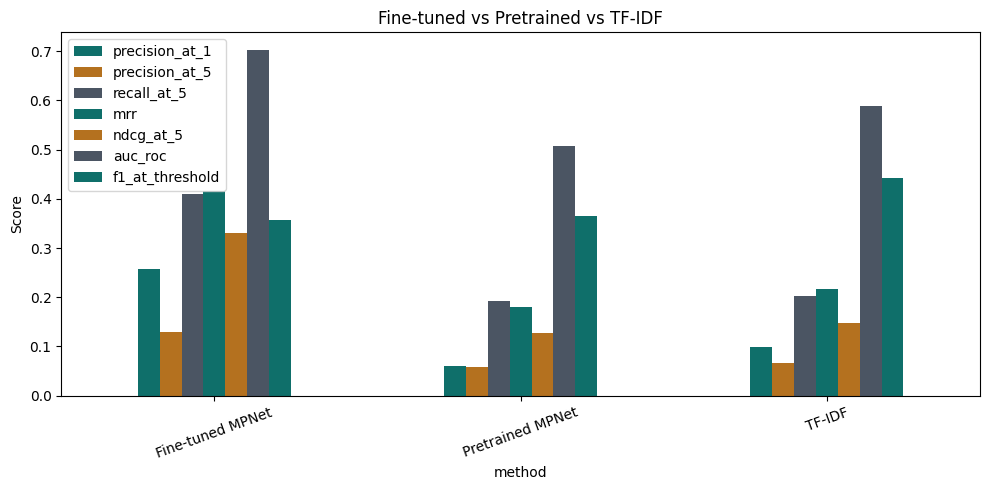

In [20]:
metrics_to_plot = [c for c in comparison_df.columns]
fig, ax = plt.subplots(figsize=(10, 5))
comparison_df[metrics_to_plot].plot(kind="bar", ax=ax, color=["#0F6F6A", "#B4711F", "#4B5563"])
ax.set_title("Fine-tuned vs Pretrained vs TF-IDF")
ax.set_ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

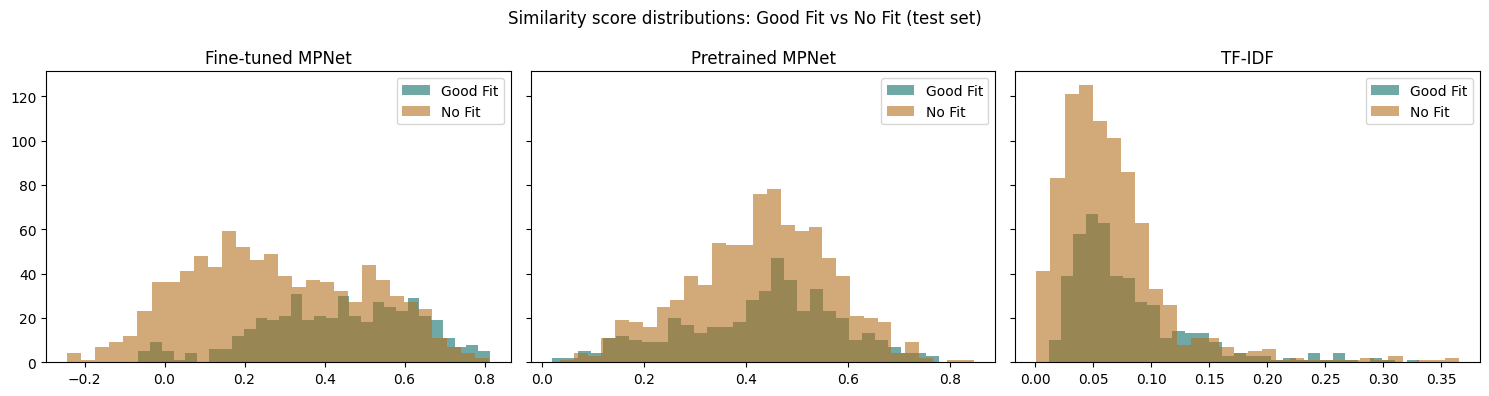

A model that learned useful signal should show LESS overlap between the two histograms than the pretrained baseline. If the fine-tuned model's histograms overlap about as much as the pretrained model's, fine-tuning did not add much for this task/dataset — that's a real, useful finding, not a failure of the notebook.


In [21]:
fig, axes = plt.subplots(1, len(similarity_distributions), figsize=(5 * len(similarity_distributions), 4), sharey=True)
if len(similarity_distributions) == 1:
    axes = [axes]

for ax, (name, (sims, y_true)) in zip(axes, similarity_distributions.items()):
    ax.hist(sims[y_true == 1], bins=30, alpha=0.6, label="Good Fit", color="#0F6F6A")
    ax.hist(sims[y_true == 0], bins=30, alpha=0.6, label="No Fit", color="#B4711F")
    ax.set_title(name)
    ax.legend()

plt.suptitle("Similarity score distributions: Good Fit vs No Fit (test set)")
plt.tight_layout()
plt.show()

print("A model that learned useful signal should show LESS overlap between the "
      "two histograms than the pretrained baseline. If the fine-tuned model's "
      "histograms overlap about as much as the pretrained model's, fine-tuning "
      "did not add much for this task/dataset — that's a real, useful finding, "
      "not a failure of the notebook.")

## 11. Inference — using the fine-tuned model directly

In [22]:
def match_resume_to_job(resume_text: str, job_text: str, model_obj=finetuned_model) -> float:
    embeddings = model_obj.encode([resume_text, job_text], convert_to_numpy=True)
    similarity = sk_cosine_similarity(embeddings[0:1], embeddings[1:2])[0][0]
    return float(similarity)


sample_resume = (
    "AI/ML Engineer with experience in Python, PyTorch, TensorFlow, and NLP. "
    "Built and deployed machine learning models using FastAPI and Docker."
)
sample_job = (
    "Looking for a Machine Learning Engineer with strong Python and PyTorch "
    "experience. NLP background preferred. Experience deploying models via APIs is a plus."
)

score = match_resume_to_job(sample_resume, sample_job)
print(f"Cosine similarity: {score:.4f}")

Cosine similarity: 0.5031


## 12. Limitations and Possible Improvements

**Known limitations of this run:**
- 8,000 rows (642 unique resumes × 280 unique job descriptions) is a modest
  dataset for fine-tuning a 110M-parameter model — expect real but limited gains
  over the pretrained baseline, not a dramatic jump.
- Hard negatives are only mined from *explicit* `No Fit` labels for the *same*
  resume; many `Good Fit` examples fall back to in-batch negatives only, which
  are weaker (random, not necessarily hard).
- `Potential Fit` rows are excluded entirely from both training and evaluation.
  This simplifies the problem but throws away roughly a third of the data's
  signal about borderline cases.
- The TF-IDF baseline uses default parameters and unigrams only — a tuned
  TF-IDF (bigrams, better stopword handling) might close some of the gap.
- No cross-validation — a single train/val/test split. Numbers may shift
  somewhat with a different random seed.

**Possible next steps, roughly in order of expected effort-to-benefit ratio:**
1. Mine multiple hard negatives per resume (currently only the first `No Fit`
   job found is used) — likely the highest-leverage, lowest-effort improvement.
2. Incorporate `Potential Fit` as a soft/intermediate signal (e.g. a
   `CoSENTLoss` or `CosineSimilarityLoss` setup with graded labels instead of
   pure contrastive pairs), rather than discarding it.
3. Combine with a second, more diverse dataset to increase resume/JD variety
   beyond 642/280 unique texts.
4. Hyperparameter sweep (learning rate, epochs, batch size) using the
   validation evaluator already wired into training.
5. Add a lightweight cross-encoder re-ranking stage on top of the bi-encoder's
   top-k retrieval results, for higher precision at the cost of latency.
6. Error analysis: manually inspect the test pairs the fine-tuned model gets
   most wrong (highest similarity for `No Fit`, lowest for `Good Fit`) to look
   for systematic patterns (e.g. seniority mismatches, industry jargon).

## Exporting the model into the FastAPI backend

The `backend/app/ml/embedding_model.py` module automatically looks for a valid
saved SentenceTransformer model at `backend/models/resume_job_mpnet_finetuned/`
(it checks for a `config_sentence_transformers.json` file in that folder). No
backend code changes are needed — just get the folder there.

**If you mounted Google Drive (Section 2b):** the folder is already saved at
your chosen Drive path. Download it from Drive and place it at
`backend/models/resume_job_mpnet_finetuned/` in your project.

**Otherwise, run the cell below** to zip and download the model directly from Colab.

In [23]:
import shutil

zip_path = shutil.make_archive(OUTPUT_MODEL_DIR, "zip", OUTPUT_MODEL_DIR)
print(f"Zipped model to: {zip_path}")

try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print("Not running in Colab — find the zip file at the path printed above "
          "and copy it into backend/models/resume_job_mpnet_finetuned/ manually.")

Zipped model to: /content/resume_job_mpnet_finetuned.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>